In [1]:
from torchvision import datasets
import torch
data_folder = 'data/FMNIST'
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

/home/liperasz/anaconda3/envs/card-21/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /home/liperasz/anaconda3/envs/card-21/lib/python3.11/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Using downloaded and verified file: data/FMNIST/FashionMNIST/raw/train-images-idx3-ubyte.gz
Extracting data/FMNIST/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FMNIST/FashionMNIST/raw

Using downloaded and verified file: data/FMNIST/FashionMNIST/raw/train-labels-idx1-ubyte.gz
Extracting data/FMNIST/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FMNIST/FashionMNIST/raw



100.0%


Extracting data/FMNIST/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FMNIST/FashionMNIST/raw



100.0%


Extracting data/FMNIST/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FMNIST/FashionMNIST/raw



In [22]:
# dados
tr_images = fmnist.data
tr_targets = fmnist.targets

In [23]:
import matplotlib.pyplot as plt
import numpy as np

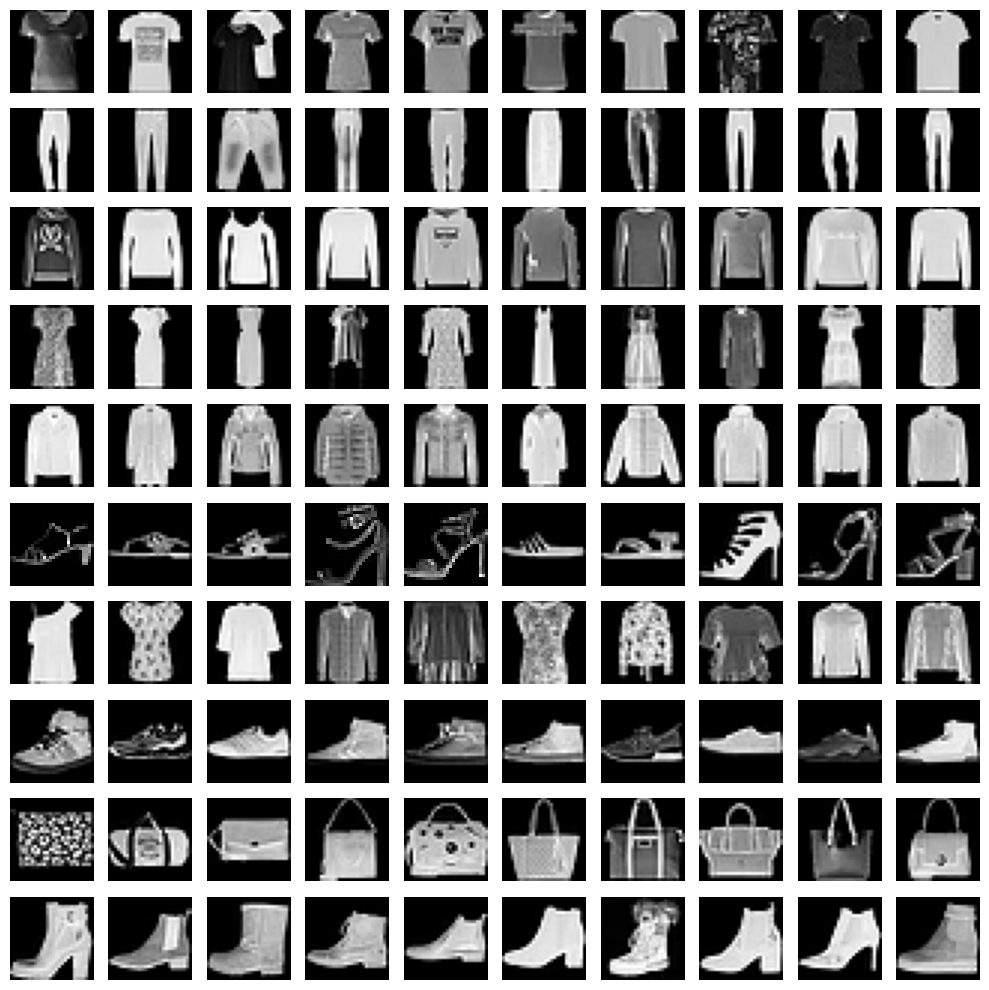

In [24]:
# mostrando 100 imagens do dataset, 10 de cada classe diferente
R, C = len(tr_targets.unique()), 10 
fig, ax = plt.subplots(R, C, figsize=(10,10)) 

for label_class, plot_row in enumerate(ax): 
    label_x_rows = np.where(tr_targets == label_class)[0] 

    for plot_cell in plot_row: 
        plot_cell.grid(False); plot_cell.axis('off') 
        ix = np.random.choice(label_x_rows) 
        x, y = tr_images[ix], tr_targets[ix]
        plot_cell.imshow(x, cmap='gray') 

# ajusta o layout
plt.tight_layout()
     


In [25]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"
from torchvision import datasets

In [26]:
# classe para o dataset
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28*28)
        self.x, self.y = x, y

    def __getitem__(self, idx):
        x, y = self.x[idx], self.y[idx]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)

In [27]:
# função para pegar os dados
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl

In [28]:
from torch.optim import SGD

# função que cria o modelo
def get_model():
    # rede neural sequencial com 2 camadas
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    # define o algoritmo de perda
    loss_fn = nn.CrossEntropyLoss() 
    # algoritmo de loss
    optimizer = SGD(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer
     


In [29]:
@torch.no_grad()
# função para calcular precisão do modelo
def accuracy(x, y, model):
    model.eval() 
    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()
     


In [30]:
# lotes de treinamento
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y) 
    batch_loss.backward() 
    optimizer.step() 
    optimizer.zero_grad()

    return batch_loss.item()

In [32]:
# carregar os dados
trn_dl = get_data()
# carregar o modelo
model, loss_fn, optimizer = get_model() 

In [33]:
# valor da perda e da precisão
losses, accuracies = [], []

# 5 épocas de treinamento
for epoch in range(5):
    print(epoch)
    epoch_losses, epoch_accuracies = [], []
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        epoch_losses.append(batch_loss)

    # perda
    epoch_loss = np.array(epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        epoch_accuracies.extend(is_correct)

    # precisão
    epoch_accuracy = np.mean(epoch_accuracies)

    # resultados
    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)
     


0
1
2
3
4


/tmp/ipykernel_36158/2019719667.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


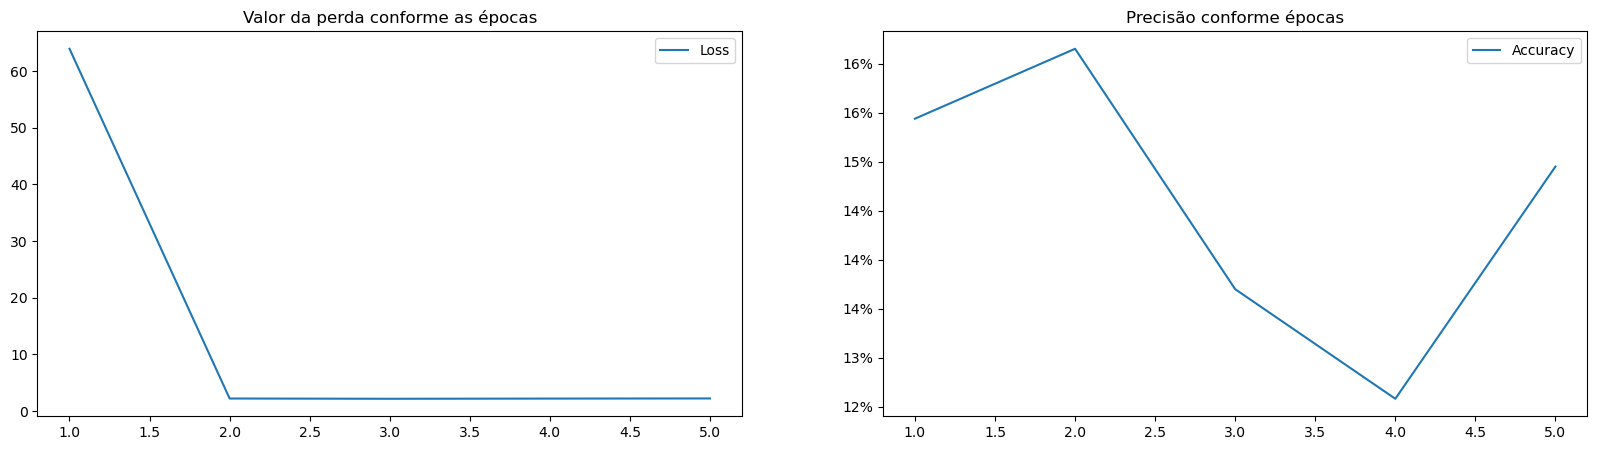

In [34]:
# 5 épocas do treinamento
epochs = np.arange(5) + 1
# tamanho da figura
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.title('Valor da perda conforme as épocas')
plt.plot(epochs, losses, label='Loss')
plt.legend()

plt.subplot(122)
plt.title('Precisão conforme épocas')
plt.plot(epochs, accuracies, label='Accuracy')

plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()